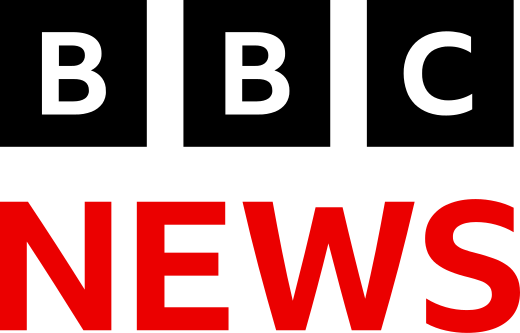

I will classify the articles from BBC News by using two datasets:
* `original_data`. This is the original dataset, that contains the BBC News articles' text and their labels.
* `data_summary`. This is a dataset that I created in **Ref. 2** by manipulating the original dataset. It contains the original articles, but also their text complexity scores and their summaries.

I will first classify the articles from the original dataset by means of Word2Vec. Then, I will compare the resulting accuracy score with the score that I get by classifying the articles' summaries in place of the original articles' text. I want to see whether the use of summarized text can improve or get worse scores.

---
### SUMMARY

1. [Read The data](#1)
2. [Exploratory Data Analysis](#2)
3. [Text Classification with Word2Vec Embedding plus Classifier](#3)
---

# 1. Read the Data
<a id="1"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_colwidth', None)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

import gensim, string, re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings("ignore")

## 1.1 Original Dataset

In [2]:
# Original BBC Articles dataset
original_data = pd.read_csv('/kaggle/input/bbc-articles-dataset/archive/bbc_text_cls.csv')

original_data.head()

,text,labels
0,"Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.\n\nThe firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.\n\nTime Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers for high-speed broadband. TimeWarner also has to restate 2000 and 2003 results following a probe by the US Securities Exchange Commission (SEC), which is close to concluding.\n\nTime Warner's fourth quarter profits were slightly better than analysts' expectations. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the third and final film in the Lord of the Rings trilogy boosted results. For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn. ""Our financial performance was strong, meeting or exceeding all of our full-year objectives and greatly enhancing our flexibility,"" chairman and chief executive Richard Parsons said. For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.\n\nTimeWarner is to restate its accounts as part of efforts to resolve an inquiry into AOL by US market regulators. It has already offered to pay $300m to settle charges, in a deal that is under review by the SEC. The company said it was unable to estimate the amount it needed to set aside for legal reserves, which it previously set at $500m. It intends to adjust the way it accounts for a deal with German music publisher Bertelsmann's purchase of a stake in AOL Europe, which it had reported as advertising revenue. It will now book the sale of its stake in AOL Europe as a loss on the value of that stake.",business
1,"Dollar gains on Greenspan speech\n\nThe dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US trade deficit is set to stabilise.\n\nAnd Alan Greenspan highlighted the US government's willingness to curb spending and rising household savings as factors which may help to reduce it. In late trading in New York, the dollar reached $1.2871 against the euro, from $1.2974 on Thursday. Market concerns about the deficit has hit the greenback in recent months. On Friday, Federal Reserve chairman Mr Greenspan's speech in London ahead of the meeting of G7 finance ministers sent the dollar higher after it had earlier tumbled on the back of worse-than-expected US jobs data. ""I think the chairman's taking a much more sanguine view on the current account deficit than he's taken for some time,"" said Robert Sinche, head of currency strategy at Bank of America in New York. ""He's taking a longer-term view, laying out a set of conditions under which the current account deficit can improve this year and next.""\n\nWorries about the deficit concerns about China do, however, remain. China's currency remains pegged to the dollar and the US currency's sharp falls in recent months have therefore made Chinese export prices highly competitive. But calls for a shift in Beijing's policy have fallen on deaf ears, despite recent comments in a maj

In [3]:
print(f'The dataset has {original_data.shape[0]} rows ans {original_data.shape[1]} columns.')

The dataset has 2225 rows ans 2 columns.


In [4]:
print(f'The dataset has {original_data.isna().sum().sum()} null values.')

The dataset has 0 null values.


In [5]:
print(f'The dataset has {original_data.duplicated().sum()} duplicate values.')

The dataset has 98 duplicate values.


I am dropping the duplicate rows.

In [6]:
original_data.drop_duplicates(inplace=True)

original_data.shape

(2127, 2)

## 1.2 Dataset with Summarized Articles

In [7]:
# Dataset with the summarized BBC News articles
data_summary = pd.read_csv('/kaggle/input/bbc-articles-dataset/bbc_news_text_complexity_summarization.csv')

data_summary.head(2)

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,"Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.\n\nThe firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.\n\nTime Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers for high-speed broadband. TimeWarner also has to restate 2000 and 2003 results following a probe by the US Securities Exchange Commission (SEC), which is close to concluding.\n\nTime Warner's fourth quarter profits were slightly better than analysts' expectations. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the third and final film in the Lord of the Rings trilogy boosted results. For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn. ""Our financial performance was strong, meeting or exceeding all of our full-year objectives and greatly enhancing our flexibility,"" chairman and chief executive Richard Parsons said. For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.\n\nTimeWarner is to restate its accounts as part of efforts to resolve an inquiry into AOL by US market regulators. It has already offered to pay $300m to settle charges, in a deal that is under review by the SEC. The company said it was unable to estimate the amount it needed to set aside for legal reserves, which it previously set at $500m. It intends to adjust the way it accounts for a deal with German music publisher Bertelsmann's purchase of a stake in AOL Europe, which it had reported as advertising revenue. It will now book the sale of its stake in AOL Europe as a loss on the value of that stake.",business,26,62.17,9.72,"It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers for high-speed broadband. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the third and final film in the Lord of the Rings trilogy boosted results. It intends to adjust the way it accounts for a deal with German music publisher Bertelsmann's purchase of a stake in AOL Europe, which it had reported as advertising revenue.","Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL. Time Warner said on Friday that it now owns 8% of search-engine Google. For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn."
1,"Dollar gains on Greenspan speech\n\nThe dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US trade deficit is set to stabilise.\n\nAnd Alan Greenspan highlighted the US government's willingness to curb spending and rising household savings as factors which may help to reduce it. In late trading in New York, the dollar reached $1.2871 again

In [8]:
print(f'The dataset has {data_summary.shape[0]} rows ans {data_summary.shape[1]} columns.')

The dataset has 2127 rows ans 7 columns.


In [9]:
print(f'The dataset has {data_summary.isna().sum().sum()} null values.')

The dataset has 0 null values.


In [10]:
print(f'The dataset has {data_summary.duplicated().sum()} duplicate values.')

The dataset has 0 duplicate values.


As expected, the two datasets have now the same number of rows.

# 2. Exploratory Data Analysis
<a id="2"></a>

## 2.1 Distribution of Target Classes

I am having a look at the distribution of the target classes.

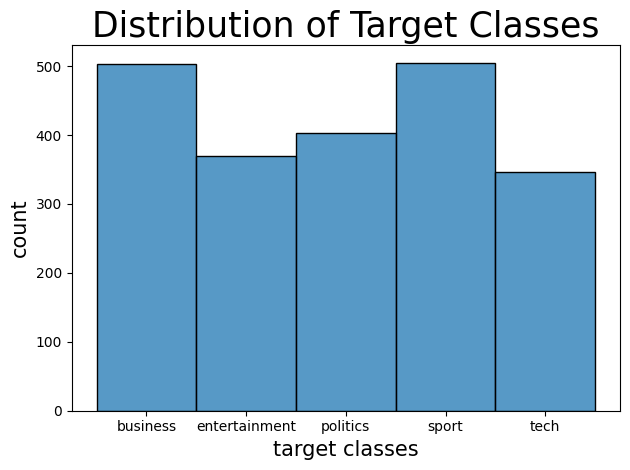

In [11]:
sns.histplot(data=original_data.labels)

plt.title('Distribution of Target Classes',fontsize=25)
plt.xlabel('target classes',fontsize=15)
plt.ylabel('count',fontsize=15)
plt.tight_layout()

There are five target classes. They are fairly spread, their relative difference being less than 20-25%. This is why there is no need of resample them in order to get reliable predictions for the minority classes.

## 2.2 Text

I want to check if the sport, business ... type articles differ by the word length, number of words, number of sentences, most frequent words, and so on.

In [12]:
# Number of sentences in the text column
data_summary['no_sentences'] = data_summary['text'].str.count('[\w][\.!\?]')

# Average number of sentences by article class
avg_no_sentences = (data_summary.groupby('labels')['no_sentences']
                    .mean().reset_index(name='avg. no. of sentences')
                    .sort_values(by='avg. no. of sentences', ascending=False))

<Figure size 1200x600 with 0 Axes>

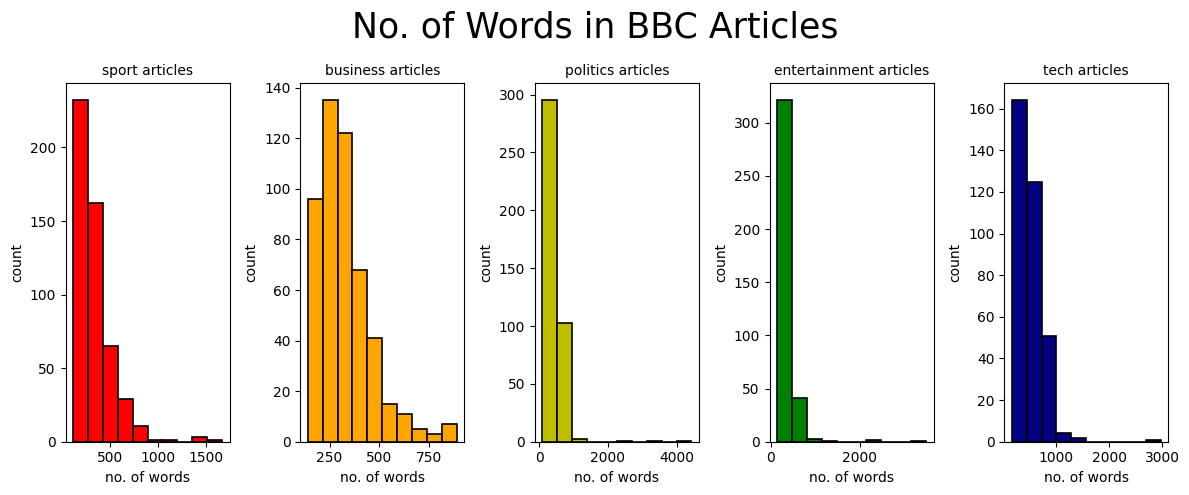

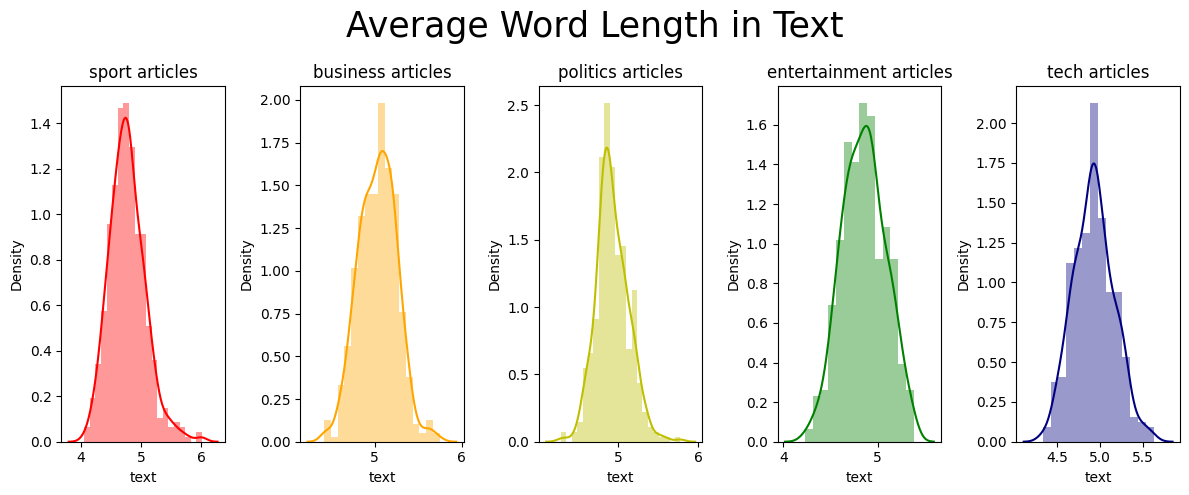

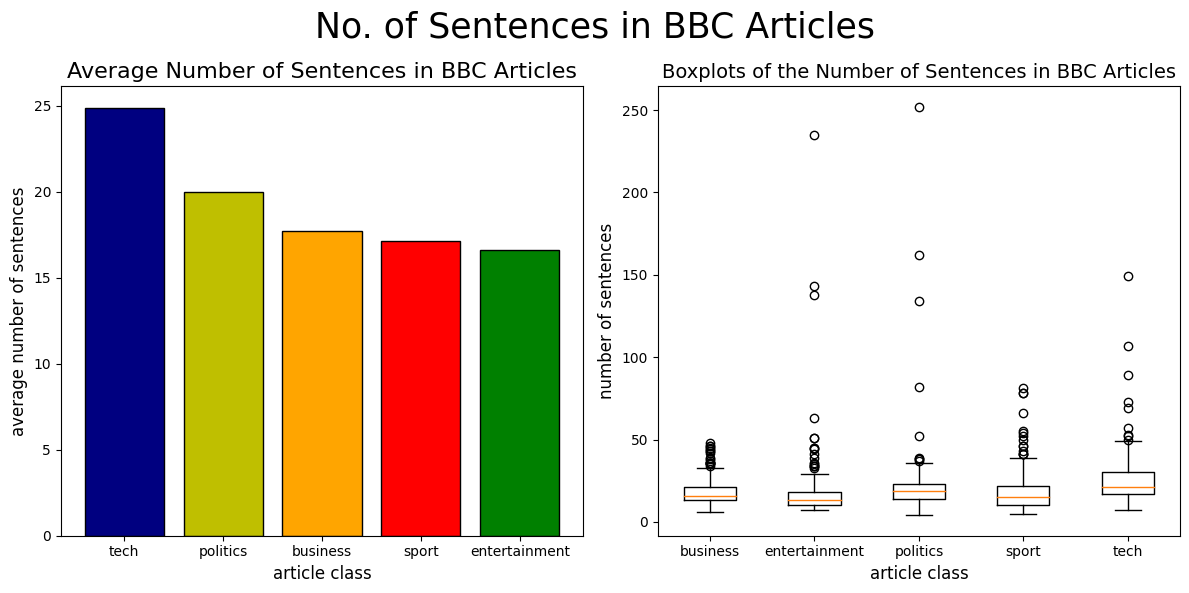

In [13]:
fig = plt.figure(figsize=(12,6))
(topfig,centralfig,bottomfig) = fig.subfigures(3,1)

### Top figures ###
topfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4)

fig,(ax1,ax2,ax3,ax4,ax5) = plt.subplots(ncols=5,figsize=(12,5))

wd_len_sp = data_summary[data_summary['labels']=='sport']['text'].str.split().map(lambda x: len(x))
ax1.hist(wd_len_sp,color='red',edgecolor='black',linewidth=1.2)
ax1.set_title('sport articles',size=10)
ax1.set_xlabel('no. of words',size=10)
ax1.set_ylabel('count',size=10)

wd_len_bus = data_summary[data_summary['labels']=='business']['text'].str.split().map(lambda x: len(x))
ax2.hist(wd_len_bus,color='orange',edgecolor='black',linewidth=1.2)
ax2.set_title('business articles',size=10)
ax2.set_xlabel('no. of words',size=10)
ax2.set_ylabel('count',size=10)

wd_len_pol = data_summary[data_summary['labels']=='politics']['text'].str.split().map(lambda x: len(x))
ax3.hist(wd_len_pol,color='y',edgecolor='black',linewidth=1.2)
ax3.set_title('politics articles',size=10)
ax3.set_xlabel('no. of words',size=10)
ax3.set_ylabel('count',size=10)

wd_len_ent = data_summary[data_summary['labels']=='entertainment']['text'].str.split().map(lambda x: len(x))
ax4.hist(wd_len_ent,color='g',edgecolor='black',linewidth=1.2)
ax4.set_title('entertainment articles',size=10)
ax4.set_xlabel('no. of words',size=10)
ax4.set_ylabel('count',size=10)

wd_len_te = data_summary[data_summary['labels']=='tech']['text'].str.split().map(lambda x: len(x))
ax5.hist(wd_len_te,color='navy',edgecolor='black',linewidth=1.2)
ax5.set_title('tech articles',size=10)
ax5.set_xlabel('no. of words',size=10)
ax5.set_ylabel('count',size=10)

plt.suptitle("No. of Words in BBC Articles",size=25)
plt.tight_layout()

### Central figure ###
centralfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4)

fig,(ax1,ax2,ax3,ax4,ax5) = plt.subplots(ncols=5,figsize=(12,5))

char_len_sp = data_summary[data_summary['labels']=='sport']['text'].str.split().apply(lambda x: [len(i) for i in x])
sns.distplot(char_len_sp.map(lambda x: np.mean(x)),ax=ax1,color='red')
ax1.set_title('sport articles',size=12)

char_len_bus = data_summary[data_summary['labels']=='business']['text'].str.split().apply(lambda x: [len(i) for i in x])
sns.distplot(char_len_bus.map(lambda x: np.mean(x)),ax=ax2,color='orange')
ax2.set_title('business articles',size=12)     

char_len_pol = data_summary[data_summary['labels']=='politics']['text'].str.split().apply(lambda x: [len(i) for i in x])
sns.distplot(char_len_pol.map(lambda x: np.mean(x)),ax=ax3,color='y')
ax3.set_title('politics articles',size=12) 

char_len_ent = data_summary[data_summary['labels']=='entertainment']['text'].str.split().apply(lambda x: [len(i) for i in x])
sns.distplot(char_len_ent.map(lambda x: np.mean(x)),ax=ax4,color='g')
ax4.set_title('entertainment articles',size=12)

char_len_te = data_summary[data_summary['labels']=='tech']['text'].str.split().apply(lambda x: [len(i) for i in x])
sns.distplot(char_len_te.map(lambda x: np.mean(x)),ax=ax5,color='navy')
ax5.set_title('tech articles',size=12)

plt.suptitle("Average Word Length in Text",size=25)
plt.tight_layout()
plt.show()

### Bottom figure ###
bottomfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4)

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1.bar(data=avg_no_sentences,x='labels',height='avg. no. of sentences',color=['navy','y','orange','red','g'],edgecolor='black')
ax1.set_xlabel('article class',size=12)
ax1.set_ylabel('average number of sentences',size=12)
ax1.set_title('Average Number of Sentences in BBC Articles',fontsize=16)

grouped = data_summary.groupby('labels')['no_sentences']
ax2.boxplot(x=[group.values for name, group in grouped],
           labels=grouped.groups.keys())
ax2.set_xlabel('article class',size=12)
ax2.set_ylabel('number of sentences',size=12)
ax2.set_title('Boxplots of the Number of Sentences in BBC Articles',fontsize=14)

plt.suptitle("No. of Sentences in BBC Articles",size=25)
plt.tight_layout()

plt.show()

Below, I am calculating the mean number of words in BBC articles by article class.

In [14]:
print(f'mean no. of words in sport articles: {wd_len_sp.mean():.1f}')
print(f'mean no. of words in business articles: {wd_len_bus.mean():.1f}')
print(f'mean no. of words in politics articles: {wd_len_pol.mean():.1f}')
print(f'mean no. of words in entertainment articles: {wd_len_ent.mean():.1f}')
print(f'mean no. of words in tech articles: {wd_len_te.mean():.1f}')

mean no. of words in sport articles: 330.6
mean no. of words in business articles: 328.7
mean no. of words in politics articles: 456.2
mean no. of words in entertainment articles: 332.7
mean no. of words in tech articles: 513.2


One can notice that there is a large difference between the total number of words depending on the article class. In particular, one can observe that politics and tech articles are on average longer than sport, business and entertainment articles. The last plots show that tech and politics articles have on average a larger number of sentences.

These differences might be explained by the articles' readability scores; see **Ref. 2**.

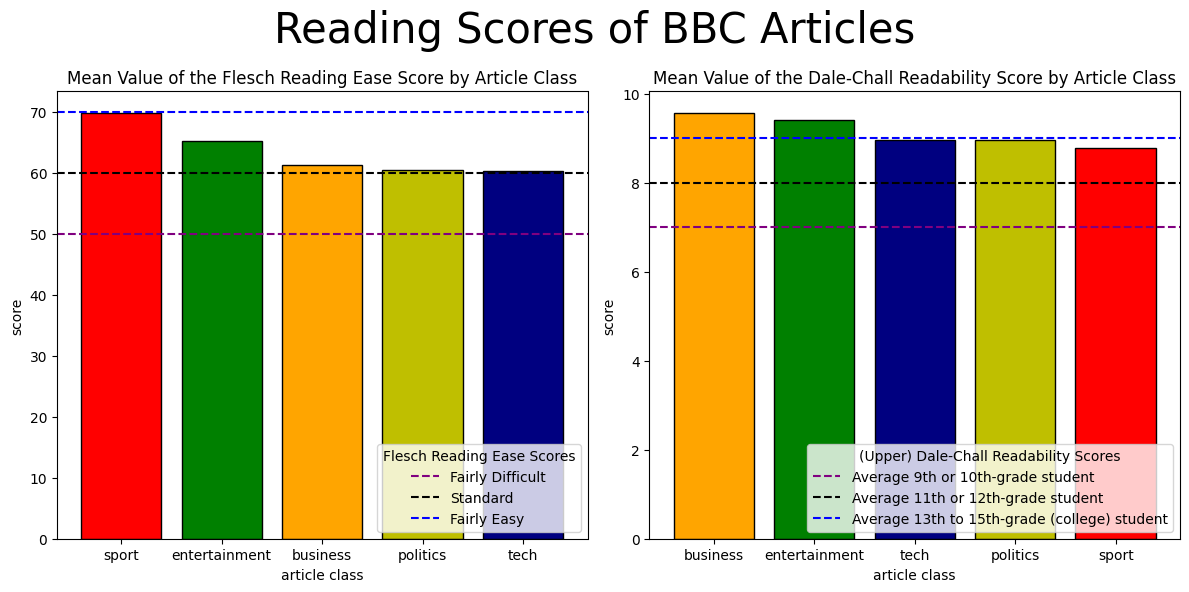

In [15]:
Dale_Chall = (data_summary.groupby('labels')['Dale-Chall Readability Score'].mean()
              .reset_index(name='mean Dale-Chall Readability Score')
              .sort_values(by='mean Dale-Chall Readability Score',ascending=False))

Flesch = (data_summary.groupby('labels')['Flesch Reading Ease Score'].mean()
          .reset_index(name='mean Flesch Reading Ease Score')
          .sort_values(by='mean Flesch Reading Ease Score',ascending=False))


fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1.bar(data=Flesch,x='labels',height='mean Flesch Reading Ease Score',
        color=['red','g','orange','y','navy'],edgecolor='black')
ax1.axhline(y=50,color='purple',linestyle='--',label='Fairly Difficult') 
ax1.axhline(y=60,color='black',linestyle='--',label='Standard') 
ax1.axhline(y=70,color='b',linestyle='--',label='Fairly Easy') 
ax1.set_title('Mean Value of the Flesch Reading Ease Score by Article Class')
ax1.set_xlabel('article class')
ax1.set_ylabel('score')
ax1.legend(loc='lower right',title='Flesch Reading Ease Scores')

ax2.bar(data=Dale_Chall,x='labels',height='mean Dale-Chall Readability Score',
        color=['orange','g','navy','y','red'],edgecolor='black')
ax2.axhline(y=7,color='purple',linestyle='--',
            label="Average 9th or 10th-grade student") 
ax2.axhline(y=8,color='black',linestyle='--',
            label="Average 11th or 12th-grade student") 
ax2.axhline(y=9,color='b',linestyle='--',
            label="Average 13th to 15th-grade (college) student") 
ax2.set_title('Mean Value of the Dale-Chall Readability Score by Article Class')
ax2.set_xlabel('article class')
ax2.set_ylabel('score')
ax2.legend(loc='lower right',title='(Upper) Dale-Chall Readability Scores')

plt.suptitle('Reading Scores of BBC Articles',size=30)

plt.tight_layout()

These plots show that:
* According to the Flesch score, business, politics and tech articles are the most difficult to read. The Dale-Chall score shows that business and entertainment articles require (on average) a college student level education.

# 3. Text Classification with Word2Vec Embedding plus Classifier
<a id="3"></a>

I will classify the BBC News Articles by means of the Word2Vec embedding plus a random forest/logistic regression classifier.

## 3.1 Classification of the 'Original' Dataset with Word2Vec

The 'original' dataset displays the text of the BBC articles before summarization. The 'summarized' dataset(s) displays their text columns, that were summarized by means of `TextRankSummarizer` and `LsaSummarizer` in **Ref. 2**. By 'text summarization' I mean a resume or abstract of the original text. <br>I want to find out whether the process of text summarization can help in the classification task or not.

The first step of the whole process is to encode the target labels.

In [16]:
encoder = LabelEncoder()

original_data['labels'] = encoder.fit_transform(original_data['labels'])

Then, I am defining the `X` and `y` variables and performing the train-test split.

In [17]:
X = original_data['text']
y = original_data['labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1488,), (639,), (1488,), (639,))

After doing this, I am filtering and tokenizing the data ...

In [18]:
stop_words = set(stopwords.words('english'))
snowballstemmer = SnowballStemmer('english')

def preprocess(text):
    text = re.sub("[^a-zA-Z]"," ",text)
    text = text.lower()
    words = nltk.word_tokenize(text)
    words = [snowballstemmer.stem(word) for word in words if word not in set(stopwords.words('english'))]
    text = ' '.join(words)
    return text

X_train = X_train.apply(preprocess)
X_test  = X_test.apply(preprocess)

... and then train the Word2Vec model using the `gensim` module. I have 'manually' scanned the parameters (`VECTOR_SIZE`, `WINDOW` and `MIN_COUNT`), in combination with the classifier, in order to optimize the classification process.

In [19]:
# Word2Vec model parameters
VECTOR_SIZE = 100 
WINDOW = 50 
MIN_COUNT = 5

sentences = [sentence.split() for sentence in X_train]

w2v_model = Word2Vec(sentences, vector_size=VECTOR_SIZE, window=WINDOW, min_count=MIN_COUNT)

Now, I am vectorizing the text by using the `Word2Vec` model above.

In [20]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if len(words_vecs) == 0:
        return np.zeros(VECTOR_SIZE)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test  = np.array([vectorize(sentence) for sentence in X_test])

Finally, I am training the classification models ...

In [21]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred_rf = rf.predict(X_test)

precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')

print('RandomForest / Precision: {} / Recall: {} / Accuracy: {}'.format(
    round(precision, 3), round(recall, 3), round((y_pred_rf==y_test).sum()/len(y_pred_rf), 3)))

RandomForest / Precision: 0.949 / Recall: 0.953 / Accuracy: 0.951


In [23]:
y_pred_lr = clf.predict(X_test)

precision = precision_score(y_test, y_pred_lr, average='macro')
recall = recall_score(y_test, y_pred_lr, average='macro')
print('LogisticRegression / Precision: {} / Recall: {} / Accuracy: {}'.format(
    round(precision, 3), round(recall, 3), round((y_pred_lr==y_test).sum()/len(y_pred_lr), 3)))

LogisticRegression / Precision: 0.945 / Recall: 0.945 / Accuracy: 0.947


A precious visualization tool to get a more general or clear picture of the results is the confusion matrix. I am plotting that of the random forest results on the test dataset.

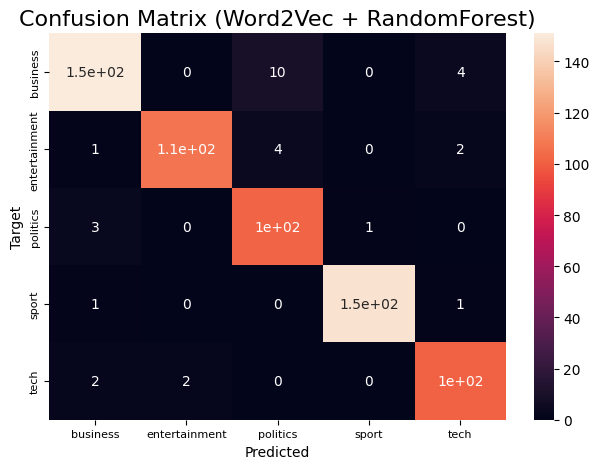

In [24]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)

ax = sns.heatmap(cm,annot=True)
ax.set_title('Confusion Matrix (Word2Vec + RandomForest)', fontsize=16)
ax.xaxis.set_ticklabels(['business','entertainment','politics','sport','tech'], fontsize=8) 
ax.yaxis.set_ticklabels(['business','entertainment','politics','sport','tech'], fontsize=8) 
ax.set_xlabel("Predicted")
ax.set_ylabel("Target")

plt.tight_layout()

## 3.2 Classification of the 'Summarized' Data

This second dataset has two columns with summarized text: `lsa_summary` and `text_rank_summary`; see **Ref. 2**.
I will be using one of these columns (`lsa_summary`) to train another classification model that is basically the same as before. Only the input data changes.

I want to find out whether classifying the summarized data instead of the 'original' data can change the accuracy of the model.

In [25]:
data_summary.drop(['text', 'no_sentences', 'Flesch Reading Ease Score',
                   'Dale-Chall Readability Score', 'text_rank_summary'], axis=1, inplace=True)

data_summary['labels'] = encoder.fit_transform(data_summary['labels'])

In [26]:
X = data_summary['lsa_summary']
y = data_summary['labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

X_train = X_train.apply(preprocess)
X_test  = X_test.apply(preprocess)

In [27]:
# Word2Vec model parameters
VECTOR_SIZE = 100 
WINDOW = 50 
MIN_COUNT = 6

sentences = [sentence.split() for sentence in X_train]
w2v_model = Word2Vec(sentences, vector_size=VECTOR_SIZE, window=WINDOW, min_count=MIN_COUNT)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test  = np.array([vectorize(sentence) for sentence in X_test])

In [28]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')

print('RandomForest / Precision: {} / Recall: {} / Accuracy: {}'.format(
    round(precision, 3), round(recall, 3), round((y_pred_rf==y_test).sum()/len(y_pred_rf), 3)))

y_pred_lr = clf.predict(X_test)

precision = precision_score(y_test, y_pred_lr, average='macro')
recall = recall_score(y_test, y_pred_lr, average='macro')
print('LogisticRegression / Precision: {} / Recall: {} / Accuracy: {}'.format(
    round(precision, 3), round(recall, 3), round((y_pred_lr==y_test).sum()/len(y_pred_lr), 3)))

RandomForest / Precision: 0.72 / Recall: 0.72 / Accuracy: 0.732
LogisticRegression / Precision: 0.346 / Recall: 0.344 / Accuracy: 0.396


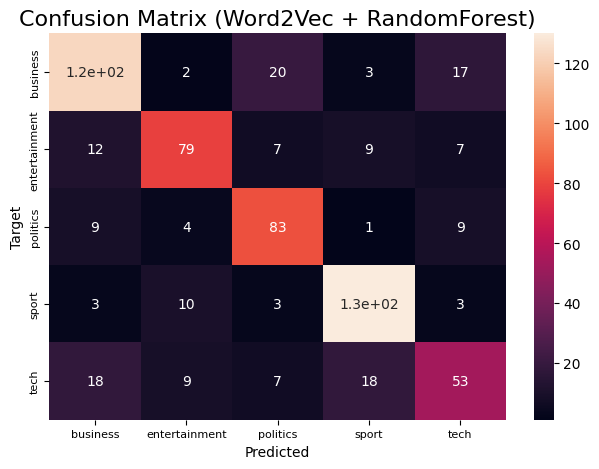

In [29]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)

ax = sns.heatmap(cm,annot=True)
ax.set_title('Confusion Matrix (Word2Vec + RandomForest)', fontsize=16)
ax.xaxis.set_ticklabels(['business','entertainment','politics','sport','tech'], fontsize=8) 
ax.yaxis.set_ticklabels(['business','entertainment','politics','sport','tech'], fontsize=8) 
ax.set_xlabel("Predicted")
ax.set_ylabel("Target")

plt.tight_layout()

# References

1. Jacopo Ferretti, [*BBC News Classification with CountVectorizer and CNNs*](https://www.kaggle.com/code/jacopoferretti/bbc-news-classification-w-countvectorizer-cnns), notebook on Kaggle.
2. Jacopo Ferretti, [*BBC News: Text Complexity and Summarization*](https://www.kaggle.com/code/jacopoferretti/bbc-news-text-complexity-and-summarization), notebook on Kaggle.
3. Raj Mehrotra, [*A Complete Text Classfication Guide(Word2Vec+LSTM)*](https://www.kaggle.com/code/rajmehra03/a-complete-text-classfication-guide-word2vec-lstm/notebook), notebook on Kaggle.
4. Neri Van Otten, [*Tutorial TF-IDF vs Word2Vec For Text Classification [How To In Python With And Without CNN]*](https://spotintelligence.com/2023/02/15/word2vec-for-text-classification/), article on spotintelligence.com.